|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Problème 10B6, Anémomètre à fil chaud



In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions
R,k,T,T_A,z,T_L,L,delta_z=sp.symbols('R,k,T,T_A,z,T_L,L,delta_z')
S=sp.symbols('S',positive=True)
h_c=sp.symbols('h_c',positive=True)
q=sp.Function('q')
T=sp.Function('T')(z)     

## Exemple d'anémomètre à fil chaud, les dimensions ne sont pas les mêmes que dans le problème 10B16.
<img src="http:\\pierreproulx.pheno.ca\hotWireAnemometer.png" width=50% height=50%>
#### Ces appareils servent à mesurer les vitesses localement dans un écoulement. Très utilisés en aérodynamique. Le principe est que quand la vitesse change, le coefficient h change, alors on peut établir une relation entre la vitesse du fluide et les mesures de courant électrique car la conductivité électrique est affectée.


### Bilan dans le fil, similaire à l'ailette de la section 10.7
###   avec trois différences:
        1- Il y a un terme de source électrique S=I**2/ke
        2- La géométrie de l'ailette est cylindrique
        3- les conditions aux limites sont que la température aux bouts 
             -L et +L est connue (TL)
             
### S=I**2/k_e, mais pour le moment on travaillera seulement avec S car c'est une constante 


#### Bilan sur une section cylindrique de l'ailette entre z et z+$\Delta$ z 
#### $ (\pi R^2 q_z)_z -(\pi R^2 q_z)_{z+\Delta z} + S \pi R^2 \Delta z - h_c 2 \pi R \Delta z (T_z-T_A) =0 $
#### donc en divisant par $\pi R^2 \Delta z$ et en faisant tendre $\Delta z$ vers 0:
#### $- \frac {dq_z}{dz} + S  - \frac {2 h_c}{R} (T_z-T_A) =0 $
#### substituant la loi de Fourier
#### $ k \frac{d^2T_z}{dz^2} - {S} + \frac {2 h_c}{R} (T_z-T_A) =0 $


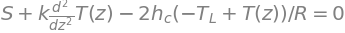

In [3]:
#
eq=sp.Eq(k*sp.diff(T,z,z)-2*h_c*(T-T_L)/(R)+S,0)
display(eq)

In [4]:
T=sp.dsolve(eq,T)
display(T)

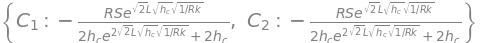

In [5]:
T=T.rhs
#
# Pose et solution des 2 équations de conditions aux limites pour C1 et C2
condition_1=sp.Eq(T.subs(z,-L)-T_L,0)
condition_2=sp.Eq(T.subs(z,L)-T_L,0)
constantes=sp.solve([condition_1,condition_2],sp.symbols('C1,C2')) # pour trouver C1 et C2
display(constantes)

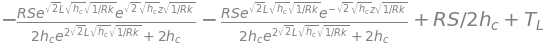

In [6]:
T=T.subs(constantes)
display(T)
T_save=T

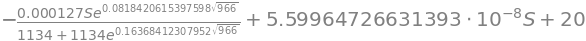

' Joules/m3-sec'

1.00937936362121


In [7]:
dico={'k':69,'L':0.005,'T_L':20,'T_A':20,'R':0.0000635}
T=T.subs(dico)
T=T.subs(h_c,567)
ke=1e7                               # valeur numérique pour k_e en ohm-1 m-1
display(T.subs(z,0))
#T=T.subs(z,0)
T=T.subs(z,0).evalf()
display(T)
solution=sp.solve(sp.Eq(T-50,0)) # résoudre pour trouver la source électrique pour 50 degrés
display(solution,' Joules/m3-sec')  # pour la conversion, 1 J/sec = 1 ampere^2 ohm
Isolution=(solution[0]*ke)**(1/2)*(sp.pi*R.subs(dico)**2)  # trouver I, la première (et seule) racine trouvée par sp.solve
print(Isolution.evalf())

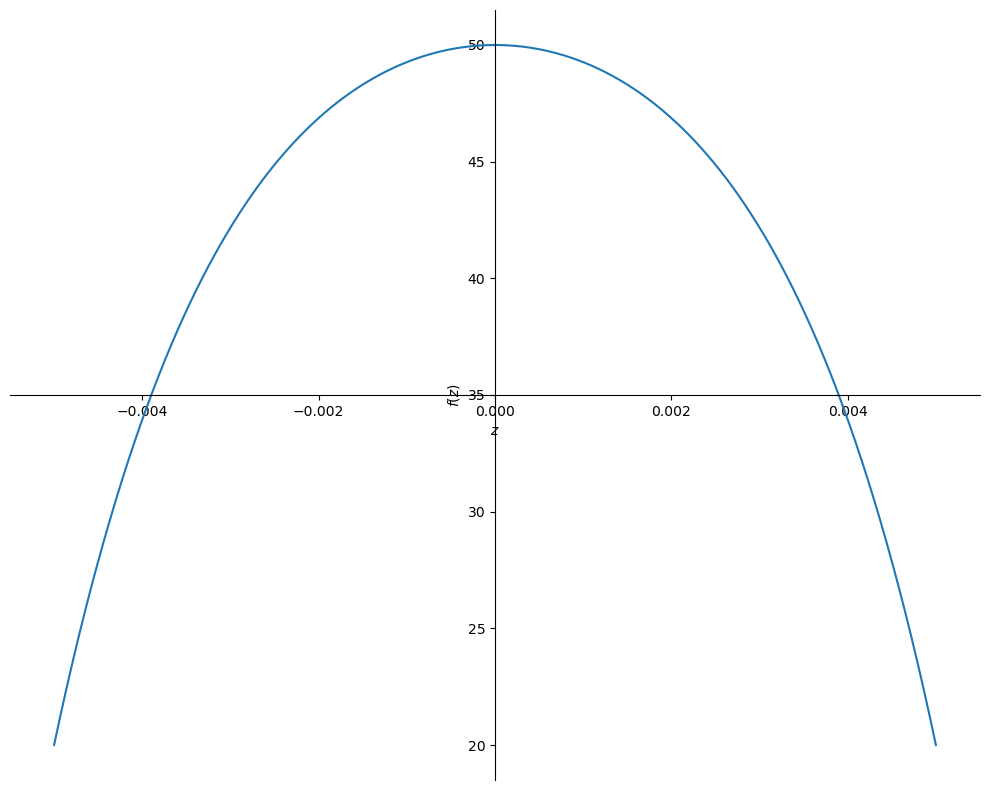

In [8]:
Tplot=T_save.subs(dico)
Tplot=Tplot.subs(h_c,567)
Tplot=Tplot.subs(S,solution[0])
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=10,8
sp.plot(Tplot,(z,-L.subs(dico),L.subs(dico)));